# 01 — Exploratory Data Analysis (EDA)

Notebook nay:
1. Thong ke tong quan dataset (so file, subjects, duration)
2. Phan phoi class (Fall vs ADL) 
3. Phan tich tin hieu 3 cam bien (ADXL, MMA, ITG)
4. So sanh AVM giua Fall vs ADL
5. t-SNE visualize kha nang phan tach
6. Inter-subject variability


In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.signal import butter, filtfilt

from data_loader import get_file_metadata, load_raw_file, butterworth_filter, compute_avm
from config import DATA_DIR, FS, SENSOR_COLS

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Setup xong!')

Setup xong!


## 1. Thong ke tong quan dataset

In [2]:
meta = get_file_metadata()
print(f'Tong so file: {len(meta)}')
print(f'Subjects: {meta["subject"].nunique()}')
print(meta.groupby(['age_group','activity_type'])['filepath'].count().rename('n_files'))
meta.head()

Tong so file: 4505
Subjects: 38
age_group  activity_type
SA         ADL              1809
           Fall             1723
SE         ADL               898
           Fall               75
Name: n_files, dtype: int64


,subject,age_group,activity_code,activity_type,label,trial,n_samples,duration_s,filepath
0,SA01,SA,D01,ADL,0,R01,19999,99.995,d:\8. 9.5 Dataset\9.5Dataset\SisFall_dataset\S...
1,SA01,SA,D02,ADL,0,R01,20000,100.000,d:\8. 9.5 Dataset\9.5Dataset\SisFall_dataset\S...
2,SA01,SA,D03,ADL,0,R01,20000,100.000,d:\8. 9.5 Dataset\9.5Dataset\SisFall_dataset\S...
3,SA01,SA,D04,ADL,0,R01,20000,100.000,d:\8. 9.5 Dataset\9.5Dataset\SisFall_dataset\S...
4,SA01,SA,D05,ADL,0,R01,5000,25.000,d:\8. 9.5 Dataset\9.5Dataset\SisFall_dataset\S...


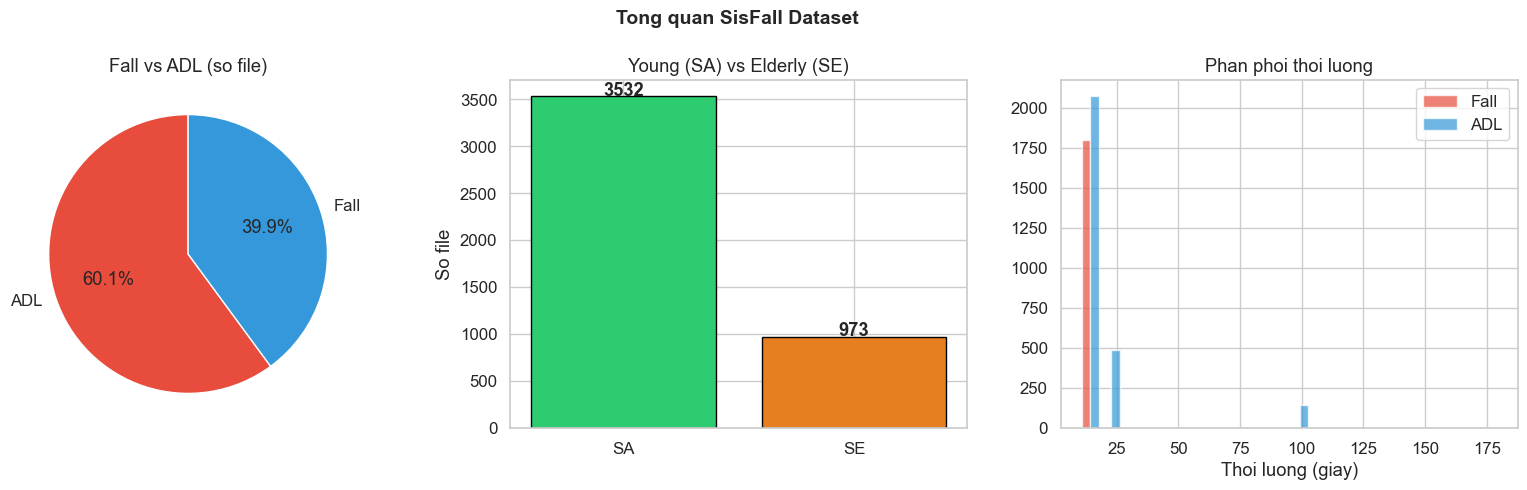

In [3]:
# Phan phoi so file theo loai hoat dong
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bieu do 1: Fall vs ADL
cnt = meta.groupby('activity_type')['filepath'].count()
axes[0].pie(cnt, labels=cnt.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#3498db'], startangle=90)
axes[0].set_title('Fall vs ADL (so file)')

# Bieu do 2: SA vs SE
cnt2 = meta.groupby('age_group')['filepath'].count()
axes[1].bar(cnt2.index, cnt2.values, color=['#2ecc71','#e67e22'], edgecolor='black')
axes[1].set_title('Young (SA) vs Elderly (SE)')
axes[1].set_ylabel('So file')
for i, v in enumerate(cnt2.values):
    axes[1].text(i, v+10, str(v), ha='center', fontweight='bold')

# Bieu do 3: Phan phoi thoi luong
axes[2].hist([meta[meta['activity_type']=='Fall']['duration_s'],
              meta[meta['activity_type']=='ADL']['duration_s']],
             bins=20, alpha=0.7, label=['Fall', 'ADL'], color=['#e74c3c', '#3498db'])
axes[2].set_xlabel('Thoi luong (giay)')
axes[2].set_title('Phan phoi thoi luong')
axes[2].legend()

plt.suptitle('Tong quan SisFall Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/eda_overview.png', dpi=150)
plt.show()

## 2. Phan tich so file theo tung activity code

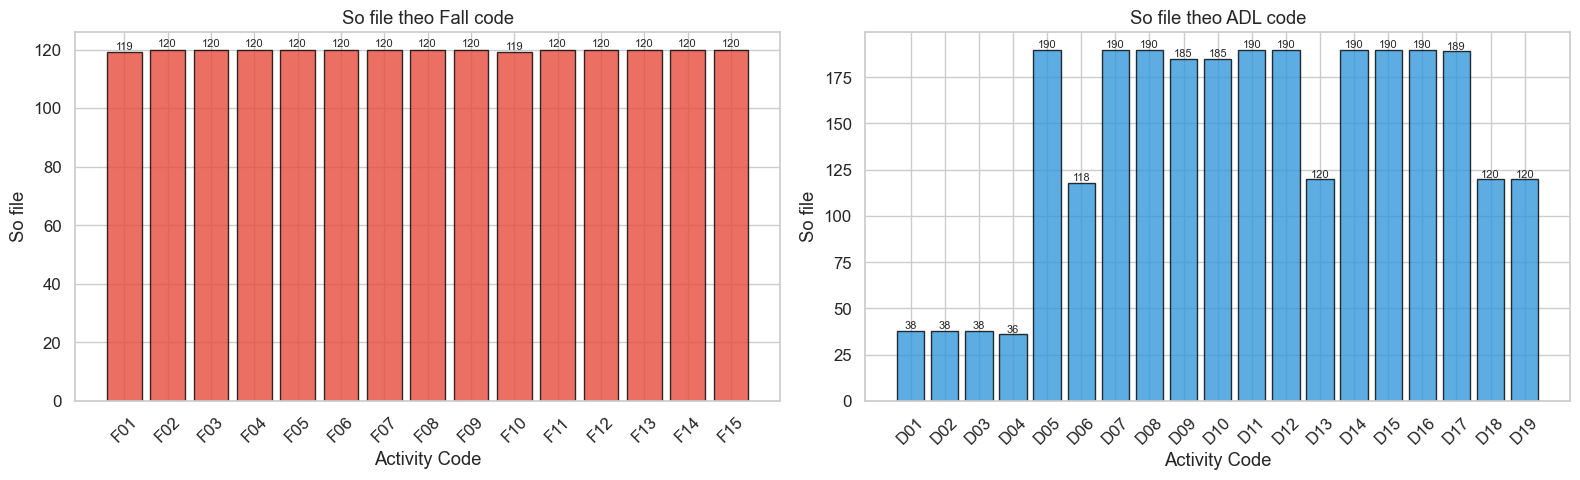

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, act_type in zip(axes, ['Fall', 'ADL']):
    df_sub = meta[meta['activity_type']==act_type]
    cnt = df_sub.groupby('activity_code')['filepath'].count().sort_index()
    ax.bar(cnt.index, cnt.values, 
           color='#e74c3c' if act_type=='Fall' else '#3498db',
           edgecolor='black', alpha=0.8)
    ax.set_title(f'So file theo {act_type} code')
    ax.set_xlabel('Activity Code')
    ax.set_ylabel('So file')
    ax.tick_params(axis='x', rotation=45)
    for i, (code, val) in enumerate(cnt.items()):
        ax.text(i, val+1, str(val), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/eda_activity_counts.png', dpi=150)
plt.show()

## 3. Phan tich tin hieu 3 cam bien: Fall vs ADL

In [5]:
# Doc 1 file Fall va 1 file ADL mau
fall_path = os.path.join(DATA_DIR, 'SA01', 'F01_SA01_R01.txt')
adl_path  = os.path.join(DATA_DIR, 'SA01', 'D01_SA01_R01.txt')

df_fall = load_raw_file(fall_path)
df_adl  = load_raw_file(adl_path)

# Loc tin hieu
fall_filt = butterworth_filter(df_fall[SENSOR_COLS].values)
adl_filt  = butterworth_filter(df_adl[SENSOR_COLS].values)

df_fall_f = pd.DataFrame(fall_filt, columns=SENSOR_COLS)
df_adl_f  = pd.DataFrame(adl_filt,  columns=SENSOR_COLS)

# Tinh AVM cho ca 3 cam bien
for df, df_f, name in [(df_fall, df_fall_f, 'Fall F01'),
                        (df_adl,  df_adl_f,  'ADL D01')]:
    print(f'--- {name} ---')
    for sensor in ['ADXL', 'MMA']:
        avm_raw  = compute_avm(df,   sensor)
        avm_filt = compute_avm(df_f, sensor)
        print(f'  {sensor}: raw_max={avm_raw.max():.3f}g  filt_max={avm_filt.max():.3f}g  std={avm_filt.std():.3f}g')
    gyro = np.sqrt(df['ITG_x']**2 + df['ITG_y']**2 + df['ITG_z']**2)
    print(f'  ITG: max={gyro.max():.1f}deg/s  mean={gyro.mean():.1f}deg/s')

--- Fall F01 ---
  ADXL: raw_max=13.796g  filt_max=3.825g  std=0.299g
  MMA: raw_max=11.790g  filt_max=3.594g  std=0.270g
  ITG: max=2308.1deg/s  mean=45.5deg/s
--- ADL D01 ---
  ADXL: raw_max=2.046g  filt_max=1.412g  std=0.148g
  MMA: raw_max=1.932g  filt_max=1.370g  std=0.142g
  ITG: max=110.0deg/s  mean=43.2deg/s


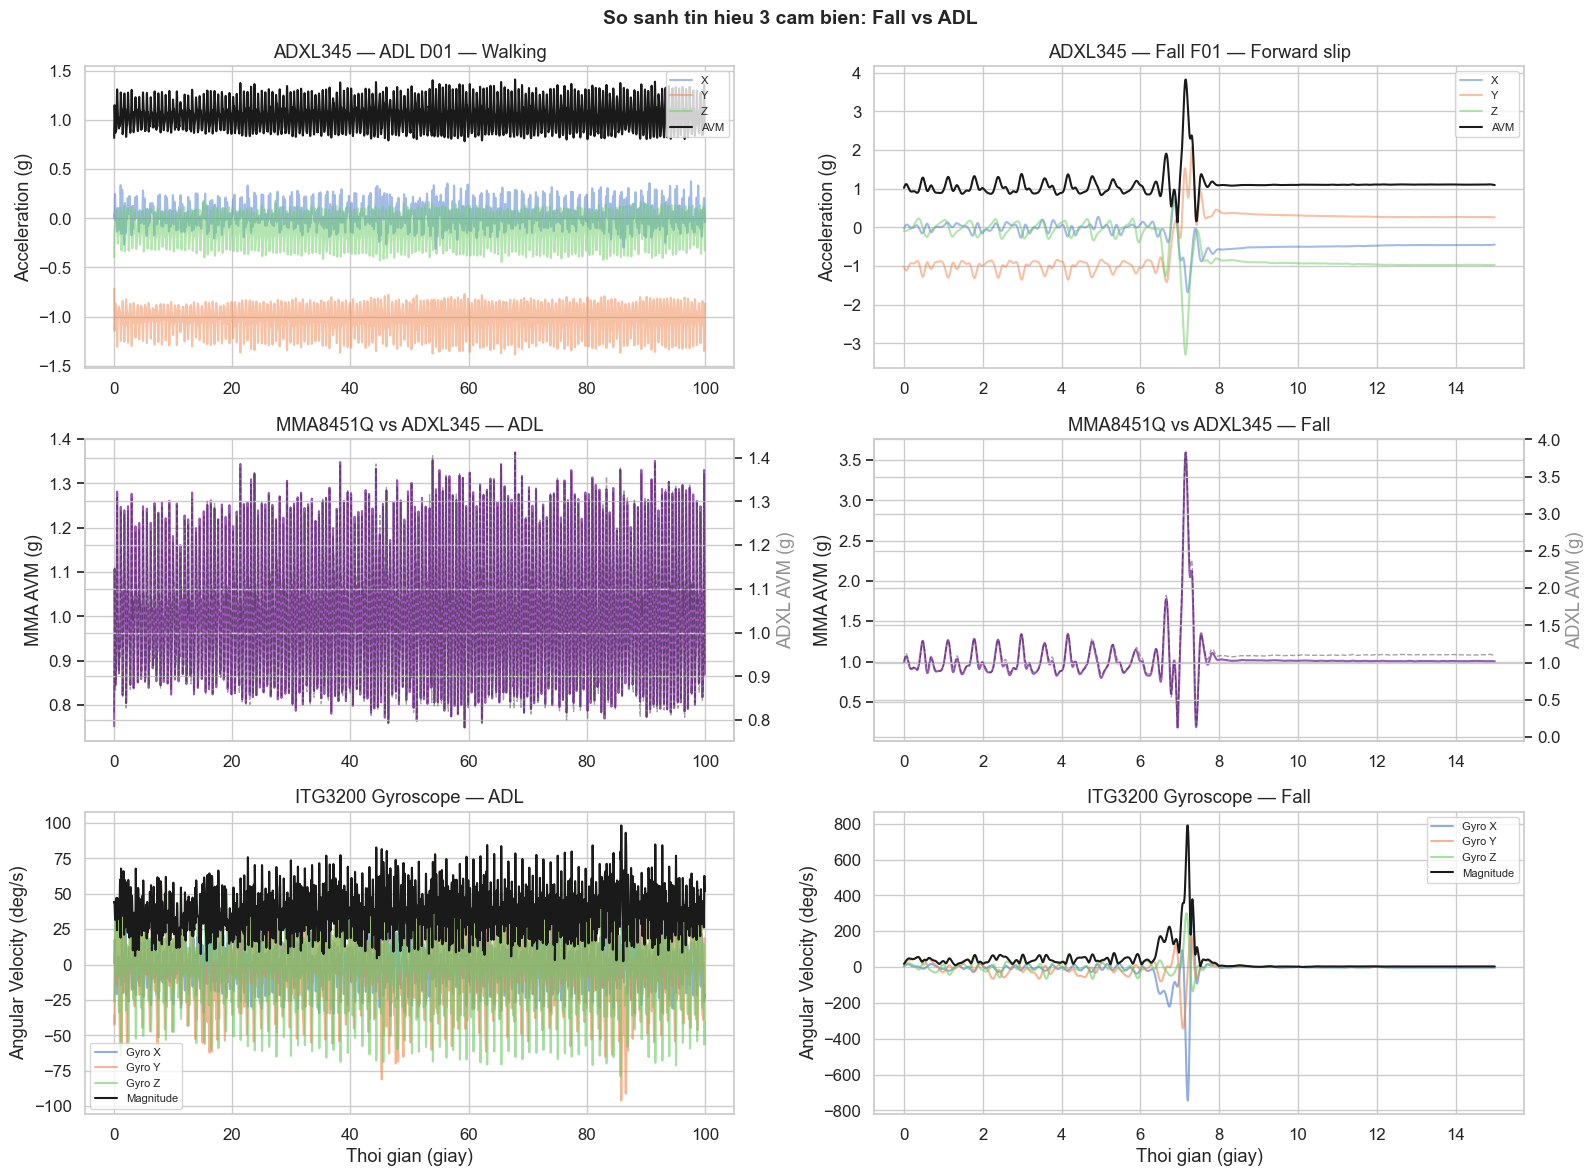

In [6]:
# Ve do thi so sanh tin hieu
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
t_fall = np.arange(len(df_fall_f)) / FS
t_adl  = np.arange(len(df_adl_f))  / FS

# --- Hang 1: ADXL AVM ---
for ax, df_f, t, name, color in [
        (axes[0,0], df_adl_f,  t_adl,  'ADL D01 — Walking', '#3498db'),
        (axes[0,1], df_fall_f, t_fall, 'Fall F01 — Forward slip', '#e74c3c')]:
    avm = compute_avm(df_f, 'ADXL')
    ax.plot(t, df_f['ADXL_x'], alpha=0.5, label='X')
    ax.plot(t, df_f['ADXL_y'], alpha=0.5, label='Y')
    ax.plot(t, df_f['ADXL_z'], alpha=0.5, label='Z')
    ax.plot(t, avm, 'k-', lw=1.5, label='AVM')
    ax.set_title(f'ADXL345 — {name}')
    ax.set_ylabel('Acceleration (g)')
    ax.legend(fontsize=8)
    ax.grid(True)

# --- Hang 2: MMA AVM ---
for ax, df_f, t, name in [
        (axes[1,0], df_adl_f,  t_adl,  'ADL'),
        (axes[1,1], df_fall_f, t_fall, 'Fall')]:
    avm = compute_avm(df_f, 'MMA')
    ax.plot(t, avm, '#9b59b6', lw=1.5, label='MMA AVM')
    ax2 = ax.twinx()
    ax2.plot(t, compute_avm(df_f, 'ADXL'), 'k--', alpha=0.4, lw=1, label='ADXL AVM')
    ax.set_title(f'MMA8451Q vs ADXL345 — {name}')
    ax.set_ylabel('MMA AVM (g)')
    ax2.set_ylabel('ADXL AVM (g)', alpha=0.5)
    ax.grid(True)

# --- Hang 3: Gyroscope ---
for ax, df_f, t, name in [
        (axes[2,0], df_adl_f,  t_adl,  'ADL'),
        (axes[2,1], df_fall_f, t_fall, 'Fall')]:
    ax.plot(t, df_f['ITG_x'], alpha=0.6, label='Gyro X')
    ax.plot(t, df_f['ITG_y'], alpha=0.6, label='Gyro Y')
    ax.plot(t, df_f['ITG_z'], alpha=0.6, label='Gyro Z')
    gyro_mag = np.sqrt(df_f['ITG_x']**2 + df_f['ITG_y']**2 + df_f['ITG_z']**2)
    ax.plot(t, gyro_mag, 'k-', lw=1.5, label='Magnitude')
    ax.set_title(f'ITG3200 Gyroscope — {name}')
    ax.set_xlabel('Thoi gian (giay)')
    ax.set_ylabel('Angular Velocity (deg/s)')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle('So sanh tin hieu 3 cam bien: Fall vs ADL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/eda_signal_comparison.png', dpi=150)
plt.show()

## 4. Thong ke AVM theo tung loai activity

In [7]:
# Tinh AVM max cho tat ca file (sample 200 file)
np.random.seed(42)
sampled = meta.sample(min(300, len(meta)))

avm_stats = []
for _, row in sampled.iterrows():
    try:
        df = load_raw_file(row['filepath'])
        df_f = pd.DataFrame(butterworth_filter(df[SENSOR_COLS].values), columns=SENSOR_COLS)
        adxl_avm = compute_avm(df_f, 'ADXL')
        mma_avm  = compute_avm(df_f, 'MMA')
        itg_mag  = np.sqrt(df_f['ITG_x']**2 + df_f['ITG_y']**2 + df_f['ITG_z']**2)
        avm_stats.append({
            'activity_code': row['activity_code'],
            'activity_type': row['activity_type'],
            'age_group':     row['age_group'],
            'ADXL_avm_max':  adxl_avm.max(),
            'MMA_avm_max':   mma_avm.max(),
            'ITG_mag_max':   itg_mag.max(),
        })
    except Exception:
        pass

df_stats = pd.DataFrame(avm_stats)
print(df_stats.groupby('activity_type')[['ADXL_avm_max','MMA_avm_max','ITG_mag_max']].describe())

              ADXL_avm_max                                                    \
                     count      mean       std       min       25%       50%   
activity_type                                                                  
ADL                  190.0  1.637473  0.594816  1.001238  1.216731  1.457684   
Fall                 110.0  3.123176  0.634486  1.787540  2.656182  3.112043   

                                  MMA_avm_max            ...            \
                    75%       max       count      mean  ...       75%   
activity_type                                            ...             
ADL            1.782961  3.778054       190.0  1.599868  ...  1.744854   
Fall           3.479365  4.786301       110.0  3.063994  ...  3.433515   

                        ITG_mag_max                                    \
                    max       count        mean        std        min   
activity_type                                                           
ADL      

C:\Users\nguye\AppData\Local\Temp\ipykernel_17644\3331407814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='activity_type', y=col, ax=ax,
C:\Users\nguye\AppData\Local\Temp\ipykernel_17644\3331407814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='activity_type', y=col, ax=ax,
C:\Users\nguye\AppData\Local\Temp\ipykernel_17644\3331407814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='activity_type', y=col, ax=ax,


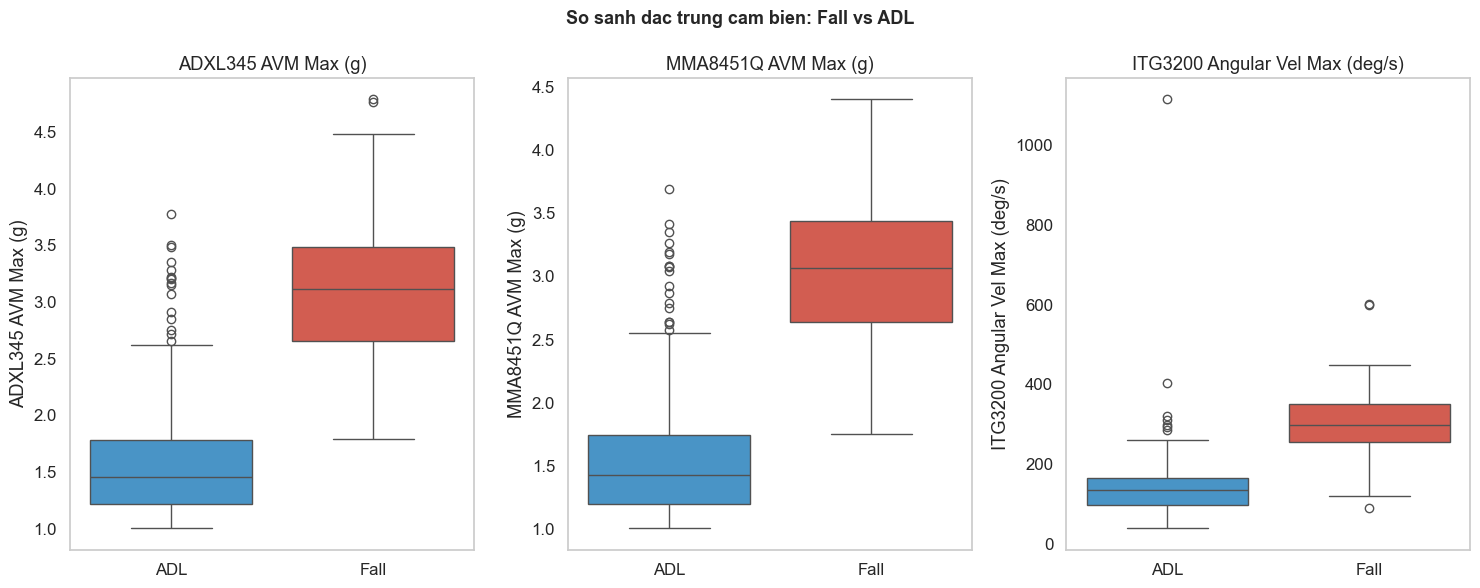

In [8]:
# Boxplot so sanh AVM max: Fall vs ADL
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
sensor_labels = [
    ('ADXL_avm_max', 'ADXL345 AVM Max (g)'),
    ('MMA_avm_max',  'MMA8451Q AVM Max (g)'),
    ('ITG_mag_max',  'ITG3200 Angular Vel Max (deg/s)'),
]
for ax, (col, label) in zip(axes, sensor_labels):
    sns.boxplot(data=df_stats, x='activity_type', y=col, ax=ax,
                palette={'Fall':'#e74c3c', 'ADL':'#3498db'},
                order=['ADL','Fall'])
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.grid(axis='y')

plt.suptitle('So sanh dac trung cam bien: Fall vs ADL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/eda_avm_boxplot.png', dpi=150)
plt.show()

## 5. Phan tich SA vs SE (inter-age group)

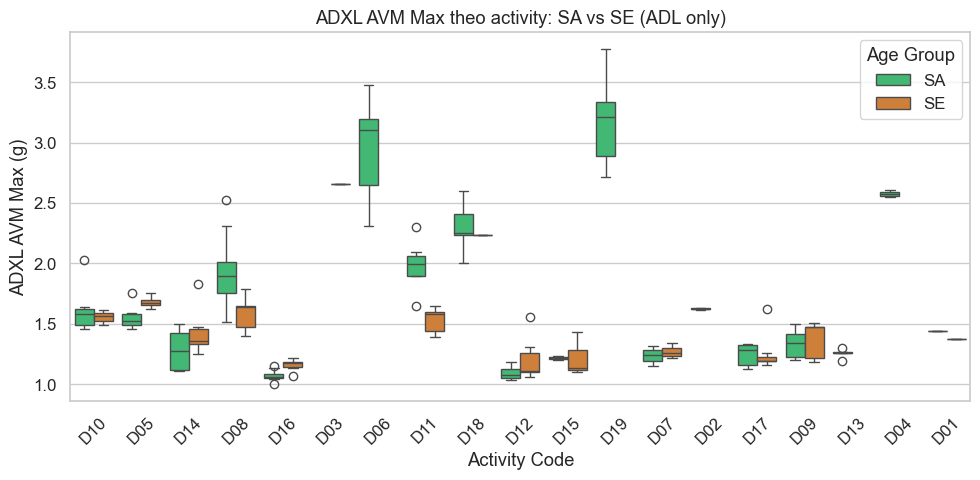

Nhan xet: Nguoi tre (SA) co AVM cao hon nguoi gia (SE) khi lam cung mot ADL.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_stats[df_stats['activity_type']=='ADL'],
            x='activity_code', y='ADXL_avm_max',
            hue='age_group', ax=ax,
            palette={'SA':'#2ecc71', 'SE':'#e67e22'})
ax.set_title('ADXL AVM Max theo activity: SA vs SE (ADL only)')
ax.set_xlabel('Activity Code')
ax.set_ylabel('ADXL AVM Max (g)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group')
plt.tight_layout()
plt.savefig('../results/figures/eda_SA_vs_SE.png', dpi=150)
plt.show()
print('Nhan xet: Nguoi tre (SA) co AVM cao hon nguoi gia (SE) khi lam cung mot ADL.')

## 6. Tuong quan giua 9 kenh cam bien

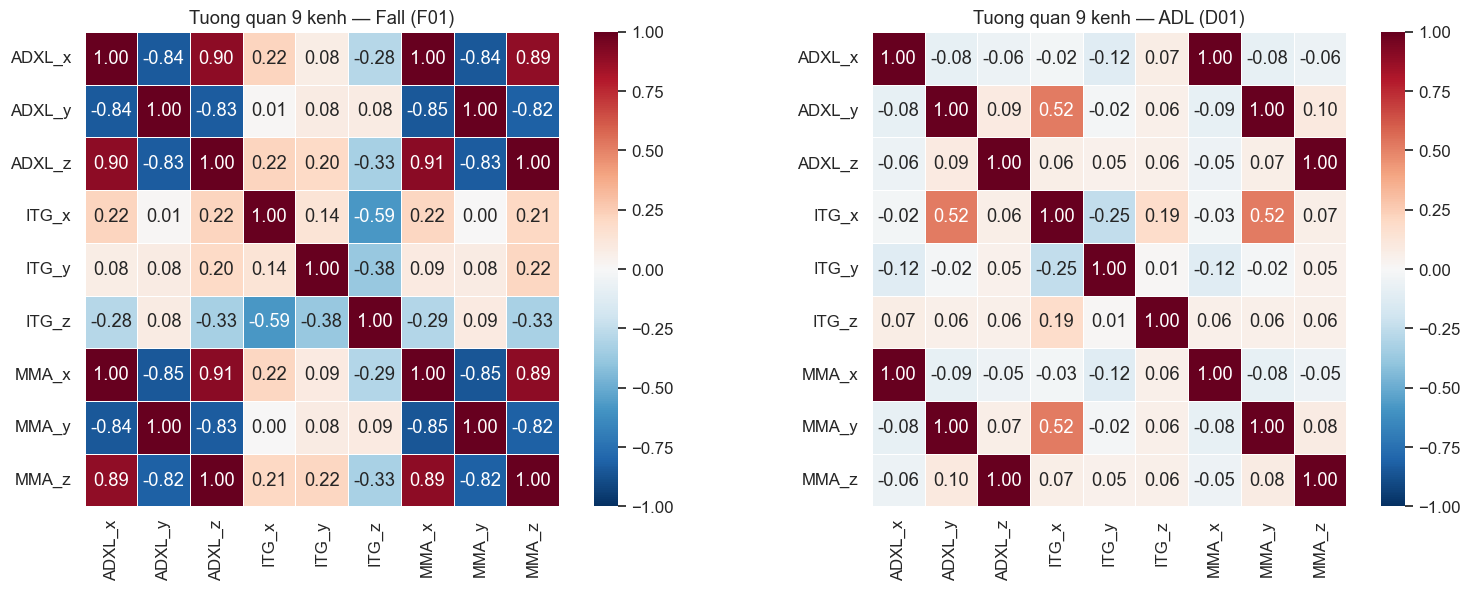

In [10]:
# Tinh tuong quan tren mot file Fall mau
df_f_fall = pd.DataFrame(butterworth_filter(
    load_raw_file(fall_path)[SENSOR_COLS].values), columns=SENSOR_COLS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df_plot, title in [
        (axes[0], df_f_fall, 'Fall (F01)'),
        (axes[1], pd.DataFrame(butterworth_filter(
            load_raw_file(adl_path)[SENSOR_COLS].values), columns=SENSOR_COLS), 'ADL (D01)')]:
    corr = df_plot.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5)
    ax.set_title(f'Tuong quan 9 kenh — {title}')

plt.tight_layout()
plt.savefig('../results/figures/eda_correlation.png', dpi=150)
plt.show()

## 7. t-SNE: Kha nang phan tach Fall vs ADL

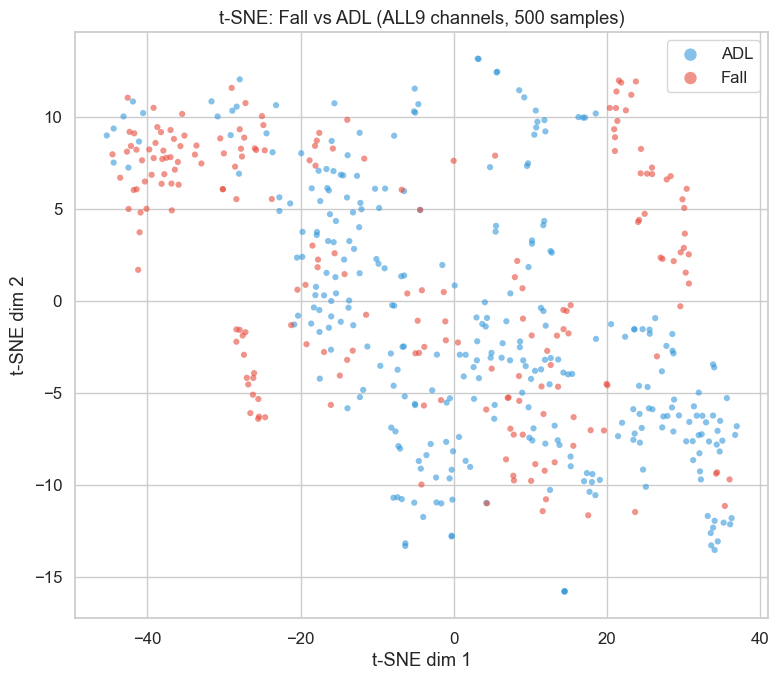

In [11]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from windowing import build_window_dataset
from features import extract_features_batch
from config import SENSOR_VARIANTS

# Lay 500 windows mau de t-SNE nhanh
sample_subjects = ['SA01', 'SA02', 'SA03', 'SE06']
X_tsne, y_tsne, _ = build_window_dataset(
    subjects=sample_subjects,
    sensor_cols=SENSOR_VARIANTS['ALL9'],
    verbose=False)

# Lay toi da 500 mau
idx = np.random.choice(len(X_tsne), min(500, len(X_tsne)), replace=False)
X_s, y_s = X_tsne[idx], y_tsne[idx]

# Trich xuat dac trung
X_feat = extract_features_batch(X_s, SENSOR_VARIANTS['ALL9'], verbose=False)
X_feat_scaled = StandardScaler().fit_transform(X_feat)

# Chay t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_feat_scaled)

fig, ax = plt.subplots(figsize=(8, 7))
colors = {0: '#3498db', 1: '#e74c3c'}
labels = {0: 'ADL', 1: 'Fall'}
for label in [0, 1]:
    mask = y_s == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[label], label=labels[label],
               alpha=0.6, s=20, edgecolors='none')
ax.set_title('t-SNE: Fall vs ADL (ALL9 channels, 500 samples)')
ax.legend(markerscale=2)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('../results/figures/eda_tsne.png', dpi=150)
plt.show()

## Ket luan EDA

| Quan sat | Nhan xet |
|----------|----------|
| Fall AVM max ~13.8g, ADL ~2g | Phan tach tot qua nguong AVM |
| ADXL va MMA tuong quan cao (>0.9) | MMA chua duoc khai thac rieng |
| ITG Gyro tap trung thap hon o ADL | Gyro them thong tin phan tach |
| SE co AVM thap hon SA cung ADL | Can cross-age evaluation |
| t-SNE cho thay 2 cum ro rang | Bai toan co kha nang phan tach tot |